- `df_raw` queda intacto, `df` es la copia de trabajo que se va limpiando.
- Salida: `data/processed/capacitaciones_limpio.csv` y `data/processed/roles_columnas.json`.

## 1. Importar herramientas

In [34]:
import csv
import json
import re
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 70)

GUARDAR_FIGURAS = True   # guarda las figuras en reports/figures/ para la presentación

## 2. Cargar el dataset

Misma carga que el EDA. Se conserva `df_raw` sin tocar y se trabaja sobre `df`.

In [35]:
def encontrar_raiz():
    p = Path.cwd().resolve()
    for c in [p, *p.parents]:
        if (c / "data").is_dir() and (c / "src").is_dir():
            return c
    raise FileNotFoundError("No se encontró la raíz del proyecto (carpetas data/ y src/).")


def cargar_dataset(ruta):
    tipos = {"NRO_DOCUMENTO": str, "FECHA_INICIO": str, "FECHA_TERMINO": str}
    for enc in ("utf-8-sig", "cp1252", "latin-1"):
        try:
            with open(ruta, encoding=enc, errors="replace") as f:
                muestra = f.read(20000)
            try:
                sep = csv.Sniffer().sniff(muestra, delimiters=",;\t|").delimiter
            except csv.Error:
                sep = ","
            return pd.read_csv(ruta, encoding=enc, sep=sep, dtype=tipos, low_memory=False), enc, sep
        except UnicodeDecodeError:
            continue
    raise ValueError("No se pudo decodificar el archivo.")


ROOT = encontrar_raiz()
RUTA = ROOT / "data" / "raw" / "Dataset_ENAP_RSCC_Dic_2025_May_2026.csv"
CARPETA_FIGURAS = ROOT / "reports" / "figures"
CARPETA_PROCESADOS = ROOT / "data" / "processed"
if not RUTA.exists():
    raise FileNotFoundError(f"No existe {RUTA}\nEjecuta primero: python src/utils/download_data.py")

df_raw, ENCODING, SEPARADOR = cargar_dataset(RUTA)
df_raw.columns = df_raw.columns.str.strip().str.upper()
df = df_raw.copy()
print(f"Leído con encoding={ENCODING!r} y separador {SEPARADOR!r} · dimensiones: {df.shape}")
df.head()

Leído con encoding='utf-8-sig' y separador ';' · dimensiones: (83930, 20)


,NRO,DEPARTAMENTO,PROVINCIA,DISTRITO,ANO_CAPACITACION,AREA,TIPO_DOCUMENTO,NRO_DOCUMENTO,BENEFICIARIO,SEXO,NIVEL_GOBIERNO,ESTADO_CAPACITACION,TRABAJA_ENTIDAD_PUBLICA,TIPO_CAPACITACION,NOMBRE_CAPACITACION,HORAS_ACADEMICAS,FECHA_INICIO,FECHA_TERMINO,MODALIDAD,TIPO_CONVOCATORIA
0,1,LORETO,MAYNAS,SAN JUAN BAUTISTA,2025,IMPLEMENTACIÓN,DNI,*********,********************,HOMBRE,NACIONAL,DESAPROBADO,SI,CURSO,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,28,20250904,20250925,REMOTA,CONCURSO PÚBLICO
1,2,CALLAO,CALLAO,CALLAO,2025,IMPLEMENTACIÓN,DNI,*********,********************,MUJER,REGIONAL,APROBADO,SI,CURSO,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,28,20250904,20250925,REMOTA,CONCURSO PÚBLICO
2,3,PIURA,AYABACA,LAGUNAS,2025,IMPLEMENTACIÓN,DNI,*********,********************,MUJER,LOCAL,APROBADO,SI,CURSO,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,28,20250904,20250925,REMOTA,CONCURSO PÚBLICO
3,4,LIMA,LIMA,JESÚS MARÍA,2025,IMPLEMENTACIÓN,DNI,*********,********************,MUJER,NACIONAL,APROBADO,SI,CURSO,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,28,20250904,20250925,REMOTA,CONCURSO PÚBLICO
4,5,AYACUCHO,HUAMANGA,AYACUCHO,2025,IMPLEMENTACIÓN,DNI,*********,********************,MUJER,REGIONAL,APROBADO,SI,CURSO,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,28,20250904,20250925,REMOTA,CONCURSO PÚBLICO


## 3. Qué hay que arreglar (según el EDA) y parámetros

| # | Hallazgo del EDA | Dónde se trata | Decisión preliminar |
|---|---|---|---|
| 1 | Textos con espacios de más, mayúsculas y tildes distintas | Bloque 1 | Normalizar |
| 2 | Fechas y horas como texto, términos anteriores al inicio (algunos en 2015) | Bloque 2 | Convertir, corregir el año si es evidente |
| 3 | `ANO_CAPACITACION` ≠ año de inicio en ~9 % | Bloque 2 | Derivar el año de `FECHA_INICIO` |
| 4 | Más de la mitad de los registros no puede «fallar» (solo asistencia) | Bloque 5 | Población: ediciones con evaluación |
| 5 | Filas idénticas (~58 %) con identidad enmascarada | Bloque 4 | No borrar |
| 6 | Horas muy asimétricas (eventos de 2 h vs. programas de ~200 h) | Bloque 6 | Marcar, no eliminar |
| 7 | Identificadores, `TIPO_DOCUMENTO` (99 % DNI) y posible fuga en `FECHA_TERMINO` | Bloque 7 | Descartar / conservar marcada |

Los umbrales de las reglas de negocio quedan aquí, en un solo lugar.

In [36]:
MAX_DUR_DIAS = 365            # una capacitación no dura más de un año
HORAS_MAX = 1000              # horas académicas por encima de esto se consideran error de registro
POBLACION = ("Con evaluación",)   # tipos de edición que entran al modelo
SIN_NORMALIZAR = ("NRO_DOCUMENTO", "BENEFICIARIO", "FECHA_INICIO", "FECHA_TERMINO")


def guardar(nombre):
    if GUARDAR_FIGURAS:
        CARPETA_FIGURAS.mkdir(parents=True, exist_ok=True)
        plt.savefig(CARPETA_FIGURAS / f"{nombre}.png", bbox_inches="tight", dpi=150)


def normalizar_texto(s):
    # forma canónica para comparar: sin tildes, sin espacios repetidos, en mayúsculas
    s = unicodedata.normalize("NFKD", str(s))
    s = "".join(c for c in s if not unicodedata.combining(c))
    return re.sub(r"\s+", " ", s).strip().upper()

# BLOQUE 1 - DIAGNÓSTICO Y CATEGORÍAS

## 4. Tipos, vacíos y vacíos "disfrazados"

Pregunta: **¿qué tipo tiene cada columna y hay datos faltantes, incluso escritos como texto?** El EDA no encontró vacíos, aquí se confirma y se buscan marcadores como `N/A` o `-`.
- `NO APLICA` no se cuenta: es una categoría real del dataset

In [37]:
diag = pd.DataFrame({"tipo": df.dtypes.astype(str), "vacíos": df.isna().sum(), "niveles": df.nunique(), "ejemplo": df.iloc[0]})
display(diag)

MARCADORES = {"", "NA", "N/A", "NULL", "NONE", "NAN", "-", "--", "S/D", "SIN DATO", "SIN DATOS"}
disfrazados = {c: int(df[c].astype(str).str.strip().str.upper().isin(MARCADORES).sum())
               for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])}
print("Vacíos reales:", int(df.isna().sum().sum()), "- Marcadores de vacío en texto:", {c: v for c, v in disfrazados.items() if v} or "ninguno")

,tipo,vacíos,niveles,ejemplo
NRO,int64,0,83930,1
DEPARTAMENTO,str,0,27,LORETO
PROVINCIA,str,0,357,MAYNAS
DISTRITO,str,0,1664,SAN JUAN BAUTISTA
ANO_CAPACITACION,int64,0,2,2025
AREA,str,0,2,IMPLEMENTACIÓN
TIPO_DOCUMENTO,str,0,9,DNI
NRO_DOCUMENTO,str,0,1,*********
BENEFICIARIO,str,0,1,********************
SEXO,str,0,2,HOMBRE


Vacíos reales: 0 - Marcadores de vacío en texto: {'DISTRITO': 1}


## 5. Normalizar categorías

Pregunta: **¿hay categorías repetidas por cómo están escritas?** El EDA detectó espacios de más en `PROVINCIA`, `DISTRITO`, `NOMBRE_CAPACITACION` y `NIVEL_GOBIERNO`, y NO/No en `TRABAJA_ENTIDAD_PUBLICA`.

- Decisión: quitar espacios sobrantes y pasar a mayúsculas, luego unir las variantes que solo difieren en tildes hacia la forma más frecuente. Los identificadores enmascarados y las fechas no se tocan. 

- Validación: comparar niveles antes y después, y revisar que no se hayan unido categorías con significado distinto.

In [38]:
cols_texto = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c]) and c not in SIN_NORMALIZAR]

filas, ejemplos = [], []
for c in cols_texto:
    n0 = df_raw[c].nunique()
    df[c] = df[c].str.strip().str.replace(r"\s+", " ", regex=True).str.upper()
    n1 = df[c].nunique()
    grupos = {}
    for v in df[c].value_counts().index:            # de más a menos frecuente
        grupos.setdefault(normalizar_texto(v), []).append(v)
    mapa = {v: vs[0] for vs in grupos.values() for v in vs}   # variante más frecuente de cada grupo
    df[c] = df[c].map(mapa)
    ejemplos += [(c, vs) for vs in grupos.values() if len(vs) > 1][:2]
    filas.append((c, n0, n1, df[c].nunique()))

cambios = pd.DataFrame(filas, columns=["columna", "niveles_originales", "tras_espacios_y_mayúsculas", "tras_unir_tildes"])
display(cambios[cambios["niveles_originales"] != cambios["tras_unir_tildes"]].reset_index(drop=True))
print("Ejemplos de variantes unidas por tildes:", ejemplos[:6] or "ninguna")

for c in ["TRABAJA_ENTIDAD_PUBLICA", "NIVEL_GOBIERNO", "MODALIDAD", "TIPO_CAPACITACION"]:
    display(df[c].value_counts(dropna=False).rename(c).to_frame())

,columna,niveles_originales,tras_espacios_y_mayúsculas,tras_unir_tildes
0,PROVINCIA,357,282,282
1,DISTRITO,1664,1547,1457
2,NIVEL_GOBIERNO,8,5,5
3,TRABAJA_ENTIDAD_PUBLICA,3,2,2
4,NOMBRE_CAPACITACION,199,192,192


Ejemplos de variantes unidas por tildes: [('DISTRITO', ['JESÚS MARÍA', 'JESUS MARIA', 'JESÚS MARIA', 'JESUS MARÍA']), ('DISTRITO', ['SAN MARTIN DE PORRES', 'SAN MARTÍN DE PORRES', 'SAN MARTÌN DE PORRES'])]


,TRABAJA_ENTIDAD_PUBLICA
TRABAJA_ENTIDAD_PUBLICA,
SI,69485
NO,14445


,NIVEL_GOBIERNO
NIVEL_GOBIERNO,
NACIONAL,42676
LOCAL,20100
REGIONAL,9827
"NO APLICA (PRIVADO, UNIVERSITARIO, LOCADOR, ETC)",7248
ORGANISMOS AUTÓNOMOS,4079


,MODALIDAD
MODALIDAD,
REMOTA,41861
E-LEARNING_MOOC,22328
PRESENCIAL,8758
E-LEARNING_CONVENCIONAL,6033
E-LEARNING,4278
HIBRIDO,390
B-LEARNING,282


,TIPO_CAPACITACION
TIPO_CAPACITACION,
EVENTO ACADÉMICO,44357
CURSO MOOC,22328
TALLER,6486
PROGRAMA,5716
CURSO,3949
MICROCURSO,1030
INNOVATHON,64


## 6. Variable objetivo `y`

`y = 1` si el estado es `DESAPROBADO` o `RETIRADO`, `y = 0` si es `APROBADO` o `ASISTIÓ`. Se comprueba que no aparezcan estados fuera de esos cuatro.

In [39]:
estado_n = df["ESTADO_CAPACITACION"].map(normalizar_texto)     # sin tildes, solo para comparar
inesperados = sorted(set(estado_n) - {"ASISTIO", "APROBADO", "DESAPROBADO", "RETIRADO"})
assert not inesperados, f"Estados fuera de la definición: {inesperados}"

df["y"] = estado_n.isin({"DESAPROBADO", "RETIRADO"}).astype(int)
display(pd.crosstab(df["ESTADO_CAPACITACION"], df["y"]))
print(f"Riesgo (y = 1): {df['y'].sum():,} registros = {df['y'].mean():.2%}")

y,0,1
ESTADO_CAPACITACION,,
APROBADO,34511,0
ASISTIÓ,47249,0
DESAPROBADO,0,2060
RETIRADO,0,110


Riesgo (y = 1): 2,170 registros = 2.59%


# BLOQUE 2 - TIPOS Y FECHAS

## 7. Convertir tipos

Horas y año pasan a número, las fechas (`AAAAMMDD`) a `datetime`. Lo que no se pueda convertir se vuelve vacío (`coerce`).

In [40]:
df["FECHA_INICIO"] = df["FECHA_INICIO"].str.strip()
df["FECHA_TERMINO"] = df["FECHA_TERMINO"].str.strip()

horas = pd.to_numeric(df["HORAS_ACADEMICAS"], errors="coerce")
ano = pd.to_numeric(df["ANO_CAPACITACION"], errors="coerce")
print("Horas no convertibles:", int((horas.isna() & df["HORAS_ACADEMICAS"].notna()).sum()),
      "| Año no convertible:", int((ano.isna() & df["ANO_CAPACITACION"].notna()).sum()))
df["HORAS_ACADEMICAS"], df["ANO_CAPACITACION"] = horas, ano

df["INICIO"] = pd.to_datetime(df["FECHA_INICIO"], format="%Y%m%d", errors="coerce")
df["TERMINO"] = pd.to_datetime(df["FECHA_TERMINO"], format="%Y%m%d", errors="coerce")
print("Fechas no interpretables -> inicio:", int(df["INICIO"].isna().sum()), "| término:", int(df["TERMINO"].isna().sum()))
print("INICIO :", df["INICIO"].min().date(), "->", df["INICIO"].max().date())
print("TERMINO:", df["TERMINO"].min().date(), "->", df["TERMINO"].max().date())

Horas no convertibles: 0 | Año no convertible: 0
Fechas no interpretables -> inicio: 0 | término: 0
INICIO : 2025-02-17 -> 2026-05-07
TERMINO: 2015-12-01 -> 2026-05-17


## 8. Fechas de término anteriores al inicio

Pregunta: **¿se pueden corregir las fechas imposibles?** El EDA encontró ~1.8 % de registros con término anterior al inicio, varios con término en 2015 (parece un error de digitación del año).

**Decisión:** si al reemplazar el año del término por el del inicio (o el siguiente) la fecha queda entre el inicio y `MAX_DUR_DIAS` días después, se corrige y se marca en `FECHA_TERMINO_CORREGIDA`. Si no es evidente, el término queda vacío en vez de inventarlo.

Término anterior al inicio: 1,498 registros (1.78%)
Año de esos términos: {2015: 1498}


,NOMBRE_CAPACITACION,FECHA_INICIO,FECHA_TERMINO,registros
0,ÉTICA E INTEGRIDAD PÚBLICA PARA LA PREVENCIÓN DE LA CORRUPCIÓN,20250407,20151201,1498


Corregidas: 1,498 | sin corrección evidente (término vacío): 0


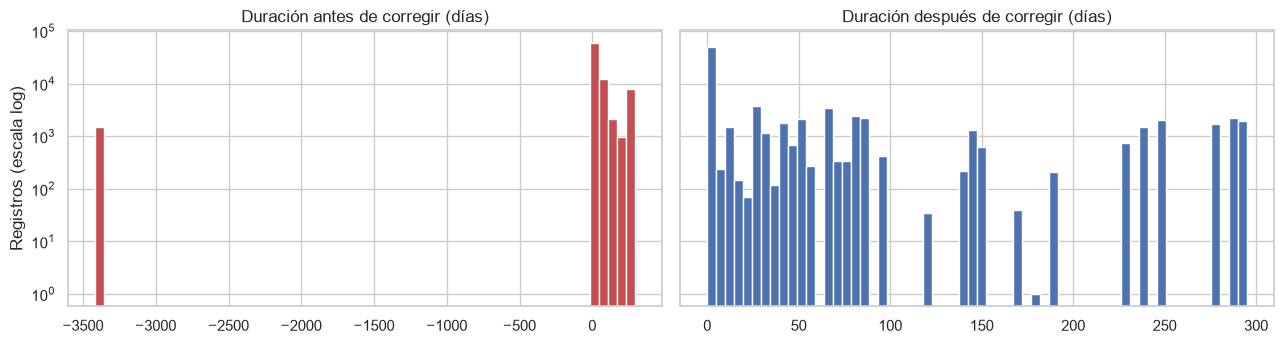

In [41]:
malas = df["TERMINO"] < df["INICIO"]
n_malas = int(malas.sum())
print(f"Término anterior al inicio: {n_malas:,} registros ({n_malas / len(df):.2%})")
print("Año de esos términos:", df.loc[malas, "TERMINO"].dt.year.value_counts().sort_index().to_dict())
display(df.loc[malas].groupby(["NOMBRE_CAPACITACION", "FECHA_INICIO", "FECHA_TERMINO"]).size()
        .rename("registros").reset_index().sort_values("registros", ascending=False).head(5))


def corregir_termino(ini, ter):
    for anio in (ini.year, ini.year + 1):
        try:
            cand = ter.replace(year=anio)
        except ValueError:          # 29 de febrero en año no bisiesto
            continue
        if ini <= cand <= ini + pd.Timedelta(days=MAX_DUR_DIAS):
            return cand
    return pd.NaT


dur_antes = (pd.to_datetime(df_raw["FECHA_TERMINO"].str.strip(), format="%Y%m%d", errors="coerce") - df["INICIO"]).dt.days

pares = df.loc[malas, ["INICIO", "TERMINO"]].drop_duplicates()
arreglo = {(i, t): corregir_termino(i, t) for i, t in zip(pares["INICIO"], pares["TERMINO"])}
nuevas = [arreglo[(i, t)] for i, t in zip(df.loc[malas, "INICIO"], df.loc[malas, "TERMINO"])]
df.loc[malas, "TERMINO"] = pd.to_datetime(pd.Series(nuevas, index=df.index[malas]))
df["FECHA_TERMINO_CORREGIDA"] = malas
df["DURACION_DIAS"] = (df["TERMINO"] - df["INICIO"]).dt.days

n_nat = int(df.loc[malas, "TERMINO"].isna().sum())
n_corr = n_malas - n_nat
print(f"Corregidas: {n_corr:,} | sin corrección evidente (término vacío): {n_nat:,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
axes[0].hist(dur_antes.clip(-4000, 500).dropna(), bins=60, color="#C44E52")
axes[0].set_title("Duración antes de corregir (días)")
axes[1].hist(df["DURACION_DIAS"].clip(upper=500).dropna(), bins=60, color="#4C72B0")
axes[1].set_title("Duración después de corregir (días)")
axes[0].set_yscale("log")
axes[0].set_ylabel("Registros (escala log)")
plt.tight_layout()
guardar("11_duracion_antes_despues")
plt.show()

## 9. Año de la capacitación

Pregunta: **¿`ANO_CAPACITACION` es el año en que empezó la capacitación?** El EDA vio que no coincide con el año de `FECHA_INICIO` en ~9 % de los registros. Se compara con el año de inicio y con el de término para saber qué representa.

`ANO_CAPACITACION` nunca es anterior al año de inicio. Los 7 848 registros que no coinciden (9.4 %) empezaron en 2025 y llevan 2026; casi todos (7 816) también terminaron en 2025, y por eso tampoco coinciden con el año de término (el resto terminó en 2026). No tienen fechas corregidas, y ~90 % viene de solo 5 ediciones que terminaron entre el 1 y el 11 de diciembre de 2025, al inicio de la ventana del reporte.

La columna no es el año de inicio ni exactamente el de término. Una hipótesis es que sea el año en que se registró o reportó el resultado, pero los datos no lo confirman. Sea cual sea su significado, depende de algo posterior al inicio.

**Decisión:** no usar `ANO_CAPACITACION`: no es el calendario de la capacitación y podría filtrar información posterior a la inscripción. Se derivan `ANIO_INICIO` y `MES_INICIO` (1–12) de `FECHA_INICIO`, que se conoce al inscribirse.

In [42]:
anio_ini = df["INICIO"].dt.year.astype("Int64")
n_ano_dif = int((df["ANO_CAPACITACION"] != anio_ini).sum())
print(f"ANO_CAPACITACION distinto del año de inicio: {n_ano_dif:,} ({n_ano_dif / len(df):.1%}) | "
      f"igual al año de término: {(df['ANO_CAPACITACION'] == df['TERMINO'].dt.year).mean():.1%}")
display(pd.crosstab(df["ANO_CAPACITACION"], anio_ini, rownames=["ANO_CAPACITACION"], colnames=["año de FECHA_INICIO"]))

df["ANIO_INICIO"] = anio_ini
df["MES_INICIO"] = df["INICIO"].dt.month

ANO_CAPACITACION distinto del año de inicio: 7,848 (9.4%) | igual al año de término: 90.7%


año de FECHA_INICIO,2025,2026
ANO_CAPACITACION,,
2025,31160,0
2026,7848,44922


In [43]:
anio_ter = df["TERMINO"].dt.year.astype("Int64")
no_coincide = (df["ANO_CAPACITACION"] != anio_ter).fillna(True)
print(f"ANO_CAPACITACION distinto del año de término: {int(no_coincide.sum()):,} ({no_coincide.mean():.1%})")

# ¿qué combinación de años tienen esos registros?
display(pd.crosstab([df.loc[no_coincide, "ANO_CAPACITACION"], anio_ini[no_coincide]], anio_ter[no_coincide],
                    rownames=["ANO_CAPACITACION", "año de inicio"], colnames=["año de término"]))

# ¿se explican por las fechas de término corregidas en la sección 8?
print(f"De ellos, con fecha de término corregida: {int((no_coincide & df['FECHA_TERMINO_CORREGIDA']).sum()):,} · "
      f"con término vacío: {int((no_coincide & df['TERMINO'].isna()).sum()):,}")

# ¿se concentran en pocas ediciones?
display(df.loc[no_coincide].groupby(["NOMBRE_CAPACITACION", "FECHA_INICIO", "FECHA_TERMINO"]).size()
        .rename("registros").reset_index().sort_values("registros", ascending=False).head(5))

ANO_CAPACITACION distinto del año de término: 7,816 (9.3%)


,año de término,2025
ANO_CAPACITACION,año de inicio,
2026,2025,7816


De ellos, con fecha de término corregida: 0 · con término vacío: 0


,NOMBRE_CAPACITACION,FECHA_INICIO,FECHA_TERMINO,registros
11,"NORMAS, TRANSPARENCIA Y LIDERAZGO ÉTICO PARA LA LUCHA CONTRA LA CO...",20251006,20251209,2291
15,PROGRAMA DE CAPACITACIÓN EN INTEGRIDAD PÚBLICA Y LUCHA CONTRA LA C...,20250407,20251209,2034
4,ESTRATEGIAS ANTICORRUPCIÓN PARA FORTALECER LA INTEGRIDAD PÚBLICA,20250707,20251201,1296
0,ACCIONES CLAVE Y RETROALIMENTACIÓN EN LA ETAPA DE EVALUACIÓN DE LA...,20251211,20251211,933
8,"II SEMINARIO INTERNACIONAL SOBRE INTEGRIDAD PÚBLICA: INNOVACIÓN, I...",20251211,20251211,451


# BLOQUE 3 - REGLAS LÓGICAS

## 10. Coherencia dentro de una edición y de la ubicación

El archivo no trae identificador de capacitación, así que se define la **edición** igual que en el EDA: nombre + fechas originales + modalidad. 

Regla de negocio: dentro de una misma edición, las **horas, el tipo y el área deben ser iguales**. Además, se revisa que la ubicación sea coherente.

**Decisión:** si hubiera conflictos, no se corrigen a mano (no hay cuál sea el valor correcto), se reportan y se decide con el caso concreto.

In [44]:
df["EDICION"] = (df["NOMBRE_CAPACITACION"].astype(str) + " | " + df["FECHA_INICIO"].astype(str)
                 + " | " + df["FECHA_TERMINO"].astype(str) + " | " + df["MODALIDAD"].astype(str))
print("Ediciones distintas:", df["EDICION"].nunique())

conflictos = {c: int((df.groupby("EDICION")[c].nunique(dropna=False) > 1).sum()) for c in ["HORAS_ACADEMICAS", "TIPO_CAPACITACION", "AREA"]}
print("Ediciones con más de un valor dentro de la misma edición:", conflictos)

homonimas = df.groupby("PROVINCIA")["DEPARTAMENTO"].nunique()
print(f"Departamentos distintos: {df['DEPARTAMENTO'].nunique()} | provincias con el mismo nombre en más de un departamento: {int((homonimas > 1).sum())}")
display(df["DEPARTAMENTO"].value_counts().tail(5).rename("registros").to_frame())

Ediciones distintas: 379
Ediciones con más de un valor dentro de la misma edición: {'HORAS_ACADEMICAS': 2, 'TIPO_CAPACITACION': 0, 'AREA': 0}
Departamentos distintos: 27 | provincias con el mismo nombre en más de un departamento: 52


,registros
DEPARTAMENTO,
APURÍMAC,832
HUANCAVELICA,804
EXTRANJERO,552
PASCO,511
MADRE DE DIOS,294


# BLOQUE 4 - DUPLICADOS

## 11. Filas idénticas

Pregunta: **¿las filas idénticas son errores de carga o personas distintas con el mismo perfil?** `NRO_DOCUMENTO` y `BENEFICIARIO` están enmascarados, así que dos participantes de la misma edición con igual perfil salen como filas iguales. Se comprueba y, además, cuántos perfiles idénticos terminan con resultados distintos (eso limita cuánto puede predecir cualquier modelo).

**Decisión:** no eliminar duplicados. Borrarlos quitaría participantes reales y distorsionaría la tasa de riesgo.

In [45]:
base = [c for c in df_raw.columns if c != "NRO"]
n_dup = int(df[base].duplicated().sum())
print(f"NRO único: {df['NRO'].is_unique} · NRO_DOCUMENTO distintos: {df_raw['NRO_DOCUMENTO'].nunique()} · BENEFICIARIO distintos: {df_raw['BENEFICIARIO'].nunique()}")
print(f"Filas idénticas (sin contar NRO): {n_dup:,} ({n_dup / len(df):.1%})")

perfil = [c for c in base if c != "ESTADO_CAPACITACION"]
gr = df.groupby(perfil, dropna=False)["y"].agg(n="size", resultados="nunique")
mixtos = gr[gr["resultados"] > 1]
print(f"Perfiles idénticos con y distinto: {len(mixtos):,} perfiles · {int(mixtos['n'].sum()):,} registros ({mixtos['n'].sum() / len(df):.1%})")

NRO único: True · NRO_DOCUMENTO distintos: 1 · BENEFICIARIO distintos: 1
Filas idénticas (sin contar NRO): 48,825 (58.2%)
Perfiles idénticos con y distinto: 614 perfiles · 6,340 registros (7.6%)


In [46]:
print(sorted(df["DEPARTAMENTO"].unique()))
display(df[df["EDICION"].isin(df.groupby("EDICION")["HORAS_ACADEMICAS"].nunique().loc[lambda s: s > 1].index)]
        .groupby(["NOMBRE_CAPACITACION", "HORAS_ACADEMICAS"]).size().rename("registros").to_frame())

['AMAZONAS', 'APURÍMAC', 'AREQUIPA', 'AYACUCHO', 'CAJAMARCA', 'CALLAO', 'CUSCO', 'EXTRANJERO', 'HUANCAVELICA', 'HUÁNUCO', 'ICA', 'JUNÍN', 'LA LIBERTAD', 'LAMBAYEQUE', 'LIMA', 'LIMA PROVINCIAS', 'LORETO', 'MADRE DE DIOS', 'MOQUEGUA', 'PASCO', 'PIURA', 'PUNO', 'SAN MARTÍN', 'TACNA', 'TUMBES', 'UCAYALI', 'ÁNCASH']


registros
NOMBRE_CAPACITACION              HORAS_ACADEMICAS           
MENTORÍA PARA LA GESTIÓN PÚBLICA 14                        2
                                 16                       30
                                 18                        5
                                 22                        1

Hay 380 ediciones. Tipo y área son consistentes dentro de cada una. Solo un curso (`MENTORÍA PARA LA GESTIÓN PÚBLICA`, 38 registros) tiene horas distintas entre participantes (14 a 22 h, 30 de los 38 con 16 h). Los 27 departamentos son los 24 departamentos más `CALLAO`, `LIMA PROVINCIAS` y `EXTRANJERO` (552 registros). Hay 52 provincias cuyo nombre aparece en más de un departamento.

La clave de edición agrupa bien. Las horas variables de la mentoría podrían ser individuales por participante (o las horas realmente cursadas, que no se saben al inscribirse), pero los datos no lo confirman, con 0.05 % de los registros no justifican cambiar la clave ni corregir valores. Los departamentos son válidos y se mantienen. Los nombres de provincia repetidos parecen homónimos reales, aunque no se verificó provincia por provincia.

**Decisión:** no se corrige nada, en el bloque de outliers se revisa si esos registros entran a la población de análisis.

# BLOQUE 5 - POBLACIÓN DE ANÁLISIS

## 12. ¿Qué ediciones pueden "fallar"?

El EDA mostró que los eventos académicos (y parte de los talleres) solo registran `ASISTIÓ`: ahí nadie desaprueba ni se retira. Se clasifica cada edición como *solo asistencia*, *con evaluación*, según los estados que tiene.

**Decisión:** el modelo trabaja solo con ediciones **con evaluación**, que son las únicas donde se puede desaprobar; así el desbalance real es ~6 % y no 2.6 %.

In [47]:
est_ed = pd.crosstab(df["EDICION"], estado_n)
asiste = est_ed["ASISTIO"] > 0 if "ASISTIO" in est_ed else pd.Series(False, index=est_ed.index)
evalua = est_ed.drop(columns=["ASISTIO"], errors="ignore").sum(axis=1) > 0
regimen = pd.Series(np.select([asiste & ~evalua, ~asiste & evalua, asiste & evalua],
                              ["Solo asistencia", "Con evaluación", "Mixta"], default="Otro"), index=est_ed.index)
df["REGIMEN"] = df["EDICION"].map(regimen)

tab = pd.crosstab(df["REGIMEN"], estado_n)
tab["registros"] = tab.sum(axis=1)
tab["ediciones"] = df.groupby("REGIMEN")["EDICION"].nunique()
tab["riesgo_%"] = ((tab.get("DESAPROBADO", 0) + tab.get("RETIRADO", 0)) / tab["registros"] * 100).round(2)
display(tab)

df_pop = df[df["REGIMEN"].isin(POBLACION)].copy()
print(f"Población de análisis: {len(df_pop):,} de {len(df):,} registros ({len(df_pop) / len(df):.0%}) · "
      f"ediciones: {df_pop['EDICION'].nunique()} · riesgo = {df_pop['y'].mean():.2%}")
print("Estados que se conservan:", estado_n[df_pop.index].value_counts().to_dict())
display(df_pop["TIPO_CAPACITACION"].value_counts().rename("registros").to_frame())

ESTADO_CAPACITACION,APROBADO,ASISTIO,DESAPROBADO,RETIRADO,registros,ediciones,riesgo_%
REGIMEN,,,,,,,
Con evaluación,34511,0,2060,110,36681,198,5.92
Solo asistencia,0,47249,0,0,47249,181,0.00


Población de análisis: 36,681 de 83,930 registros (44%) · ediciones: 198 · riesgo = 5.92%
Estados que se conservan: {'APROBADO': 34511, 'DESAPROBADO': 2060, 'RETIRADO': 110}


,registros
TIPO_CAPACITACION,
CURSO MOOC,22328
PROGRAMA,5716
CURSO,3949
TALLER,3594
MICROCURSO,1030
INNOVATHON,64


Ninguna edición mezcla `ASISTIÓ` con estados de evaluación, son 198 ediciones con evaluación (36 681 registros, riesgo 5.92 %) y 181 de solo asistencia (47 249 registros, sin ningún caso de riesgo). El filtro conserva los 2 060 desaprobados y los 110 retirados. La población está dominada por `CURSO MOOC` (61 %).

Los eventos y parte de las capacitaciones no pueden fallar por diseño, así que dejarlos diluiría el riesgo (2.6 % vs 5.9 %) sin aportar información. En la población, `y = 0` equivale a `APROBADO`. El predominio de MOOC hará que pocas ediciones pesen mucho en el modelo, otra razón para separar train y test por edición.

# BLOQUE 6 - OUTLIERS

## 13. Horas académicas

Pregunta: **¿qué horas son errores y cuáles son simplemente programas largos?**

Se distingue una regla de negocio (horas ≤ 0 o > `HORAS_MAX` son inválidas por definición) de un extremo estadístico (IQR). Como las horas dependen del tipo de capacitación, el IQR se calcula dentro de cada tipo.

**Decisión:** lo inválido por regla pasa a vacío, los extremos estadísticos se marcan, no se eliminan: un programa de 200 h no es un error. Se comprueba además si los extremos tienen un riesgo distinto.

Horas inválidas por regla (nulas, < 1 o > 1000): 0


,registros,mediana_h,max_h,atípicas
TIPO_CAPACITACION,,,,
CURSO,3949,26.0,50.0,362
CURSO MOOC,22328,24.0,40.0,6230
INNOVATHON,64,24.0,24.0,0
MICROCURSO,1030,4.0,4.0,0
PROGRAMA,5716,28.0,234.0,270
TALLER,3594,4.0,22.0,956


,registros,riesgo
HORAS_ATIPICA,,
False,28863,0.0474
True,7818,0.1025


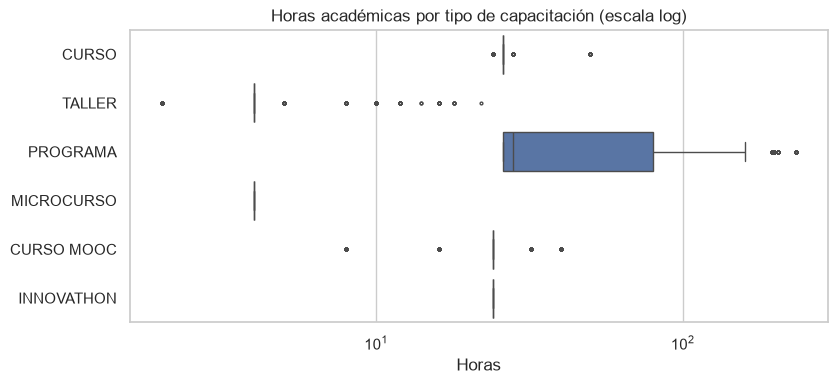

In [48]:
h = df_pop["HORAS_ACADEMICAS"]
invalidas = h.isna() | ~h.between(1, HORAS_MAX)
print(f"Horas inválidas por regla (nulas, < 1 o > {HORAS_MAX}): {int(invalidas.sum())}")
df_pop.loc[invalidas, "HORAS_ACADEMICAS"] = np.nan

g = df_pop.groupby("TIPO_CAPACITACION")["HORAS_ACADEMICAS"]
q1, q3 = g.transform(lambda s: s.quantile(0.25)), g.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
h = df_pop["HORAS_ACADEMICAS"]
df_pop["HORAS_ATIPICA"] = ((h < q1 - 1.5 * iqr) | (h > q3 + 1.5 * iqr)).fillna(False)

display(df_pop.groupby("TIPO_CAPACITACION").agg(registros=("y", "size"), mediana_h=("HORAS_ACADEMICAS", "median"),
                                               max_h=("HORAS_ACADEMICAS", "max"), atípicas=("HORAS_ATIPICA", "sum")))
display(df_pop.groupby("HORAS_ATIPICA")["y"].agg(registros="size", riesgo="mean").round(4))

plt.figure(figsize=(9, 3.8))
sns.boxplot(data=df_pop, y="TIPO_CAPACITACION", x="HORAS_ACADEMICAS", color="#4C72B0", fliersize=2)
plt.xscale("log")
plt.title("Horas académicas por tipo de capacitación (escala log)")
plt.xlabel("Horas")
plt.ylabel("")
guardar("12_horas_por_tipo")
plt.show()

Se comprueba que no se rompe la regla establecida, también se observan los posibles outliers en la categoria PROGRAMA, esos valores no se descartan.

## 14. Duración en días

La duración depende de la fecha de término, que ya se corrigió en la sección 8. Se marcan las duraciones mayores a `MAX_DUR_DIAS`, no se borran ni se vuelven vacías porque un programa largo puede durar más de un año.

In [53]:
df_pop["DURACION_ATIPICA"] = df_pop["DURACION_DIAS"] > MAX_DUR_DIAS
print(df_pop["DURACION_DIAS"].describe(percentiles=[0.5, 0.95, 0.99]).round(1).to_dict())
print(f"Duraciones > {MAX_DUR_DIAS} días: {int(df_pop['DURACION_ATIPICA'].sum())} | duración vacía: {int(df_pop['DURACION_DIAS'].isna().sum())}")

{'count': 36681.0, 'mean': 113.3, 'std': 102.4, 'min': 0.0, '50%': 68.0, '95%': 295.0, '99%': 295.0, 'max': 295.0}
Duraciones > 365 días: 0 | duración vacía: 0


# BLOQUE 7 - COLUMNAS, VALIDACIÓN Y GUARDADO

## 15. Qué columnas se quedan y con qué rol

Se descartan los identificadores y columnas redundantes o sin información. `ESTADO_CAPACITACION` se conserva solo para el análisis de errores: **nunca como predictora** (es el origen de `y`). `DURACION_DIAS` queda marcada **revisar fuga**: puede reflejar la fecha real de cierre, que no se sabe al inscribirse. `NOMBRE_CAPACITACION`, `PROVINCIA` y `DISTRITO` quedan como referencia por su alta cardinalidad, `EDICION` se guarda para separar train/test por edición en una etapa futura.

In [54]:
cand = ["DEPARTAMENTO", "SEXO", "NIVEL_GOBIERNO", "TRABAJA_ENTIDAD_PUBLICA", "AREA", "TIPO_CAPACITACION", "MODALIDAD", "TIPO_CONVOCATORIA"]
dom = pd.DataFrame([(c, df_pop[c].nunique(), df_pop[c].value_counts().index[0], df_pop[c].value_counts(normalize=True).iloc[0] * 100)
                    for c in cand + ["TIPO_DOCUMENTO"]], columns=["columna", "niveles", "valor_dominante", "%_dominante"]).round(1)
display(dom.sort_values("%_dominante", ascending=False).reset_index(drop=True))

DESCARTAR = ["NRO", "NRO_DOCUMENTO", "BENEFICIARIO", "TIPO_DOCUMENTO", "ANO_CAPACITACION", "FECHA_INICIO", "FECHA_TERMINO", "REGIMEN"]
constantes = [c for c in cand if df_pop[c].nunique(dropna=False) == 1]
print("Constantes en la población (se descartan):", constantes or "ninguna")

ROLES = {
    "agrupacion": ["EDICION"],
    "objetivo": ["y"],
    "origen_objetivo_no_usar_como_predictora": ["ESTADO_CAPACITACION"],
    "predictoras_candidatas": [c for c in cand + ["HORAS_ACADEMICAS", "MES_INICIO", "ANIO_INICIO"] if c not in constantes],
    "revisar_fuga": ["DURACION_DIAS"],
    "referencia": ["NOMBRE_CAPACITACION", "PROVINCIA", "DISTRITO", "INICIO", "TERMINO"],
    "banderas_calidad": ["FECHA_TERMINO_CORREGIDA", "HORAS_ATIPICA", "DURACION_ATIPICA"],
}
orden = [c for grupo in ROLES.values() for c in grupo]
df_final = df_pop[orden].reset_index(drop=True)
print(f"Columnas: {df_raw.shape[1]} originales → {df_final.shape[1]} en el dataset limpio | descartadas: {sorted(set(DESCARTAR) | set(constantes))}")

,columna,niveles,valor_dominante,%_dominante
0,AREA,1,IMPLEMENTACIÓN,100.0
1,TIPO_DOCUMENTO,7,DNI,98.7
2,TIPO_CONVOCATORIA,7,ABIERTA,78.5
3,TRABAJA_ENTIDAD_PUBLICA,2,SI,75.7
4,NIVEL_GOBIERNO,5,NACIONAL,70.6
5,TIPO_CAPACITACION,6,CURSO MOOC,60.9
6,MODALIDAD,7,E-LEARNING_MOOC,60.9
7,SEXO,2,HOMBRE,52.4
8,DEPARTAMENTO,27,LIMA,43.9


Constantes en la población (se descartan): ['AREA']
Columnas: 20 originales → 22 en el dataset limpio | descartadas: ['ANO_CAPACITACION', 'AREA', 'BENEFICIARIO', 'FECHA_INICIO', 'FECHA_TERMINO', 'NRO', 'NRO_DOCUMENTO', 'REGIMEN', 'TIPO_DOCUMENTO']


In [55]:
display(pd.crosstab(df_pop["TIPO_CAPACITACION"], df_pop["MODALIDAD"]))
display(df_pop.assign(DNI=df_pop["TIPO_DOCUMENTO"] == "DNI").groupby("DNI")["y"].agg(registros="size", riesgo="mean").round(4))

MODALIDAD,B-LEARNING,E-LEARNING,E-LEARNING_CONVENCIONAL,E-LEARNING_MOOC,HIBRIDO,PRESENCIAL,REMOTA
TIPO_CAPACITACION,,,,,,,
CURSO,78,0,3587,0,0,30,254
CURSO MOOC,0,0,0,22328,0,0,0
INNOVATHON,0,0,0,0,64,0,0
MICROCURSO,0,1030,0,0,0,0,0
PROGRAMA,34,3248,2034,0,0,0,400
TALLER,170,0,0,0,0,369,3055


,registros,riesgo
DNI,,
False,494,0.0445
True,36187,0.0594


`TIPO_CAPACITACION` y `MODALIDAD` coinciden uno a uno en `CURSO MOOC` <-> `E-LEARNING_MOOC`, `MICROCURSO` <-> `E-LEARNING` e `INNOVATHON` <-> `HIBRIDO`; en `CURSO`, `PROGRAMA` y `TALLER` se reparten en varias modalidades. Los 494 registros con documento distinto de DNI tienen un riesgo de 4.45 %, frente a 5.94 % de los DNI.

Las dos variables se solapan pero no son idénticas, así que se mantienen ambas; habrá que vigilar la colinealidad en el modelo lineal y no atribuir un efecto a una sola. La diferencia por tipo de documento es pequeña y de un grupo chico (~22 casos de riesgo), por lo que no justifica conservar `TIPO_DOCUMENTO`.

## 16. Validar y guardar

Se comprueban las reglas sobre el resultado final. Los vacíos que queden (horas inválidas, términos sin corrección evidente).

In [51]:
texto_final = [c for c in cols_texto if c in df_final.columns]
checks = pd.Series({
    "y solo toma 0 y 1": set(df_final["y"].unique()) <= {0, 1},
    "ESTADO_CAPACITACION fuera de las predictoras": "ESTADO_CAPACITACION" not in ROLES["predictoras_candidatas"],
    "solo ediciones con evaluación": df_final["EDICION"].isin(regimen[regimen.isin(POBLACION)].index).all(),
    "horas > 0 (o vacías)": ((df_final["HORAS_ACADEMICAS"] > 0) | df_final["HORAS_ACADEMICAS"].isna()).all(),
    "término ≥ inicio (o vacío)": ((df_final["TERMINO"] >= df_final["INICIO"]) | df_final["TERMINO"].isna()).all(),
    "texto sin espacios de más": all((df_final[c].fillna("") == df_final[c].fillna("").str.strip()).all() for c in texto_final),
}, name="cumple")
display(checks.to_frame())
assert checks.all(), "Alguna regla de calidad no se cumple"

display(df_final[ROLES["predictoras_candidatas"] + ["DURACION_DIAS"]].isna().sum().rename("vacíos").loc[lambda s: s > 0].to_frame())

CARPETA_PROCESADOS.mkdir(parents=True, exist_ok=True)
RUTA_SALIDA = CARPETA_PROCESADOS / "capacitaciones_limpio.csv"
df_final.to_csv(RUTA_SALIDA, index=False, encoding="utf-8-sig")
(CARPETA_PROCESADOS / "roles_columnas.json").write_text(json.dumps(ROLES, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Guardado: {RUTA_SALIDA.relative_to(ROOT)} · {df_final.shape}")
df_final.head()

,cumple
y solo toma 0 y 1,True
ESTADO_CAPACITACION fuera de las predictoras,True
solo ediciones con evaluación,True
horas > 0 (o vacías),True
término ≥ inicio (o vacío),True
texto sin espacios de más,True


,vacíos


Guardado: data\processed\capacitaciones_limpio.csv · (36681, 22)


,EDICION,y,ESTADO_CAPACITACION,DEPARTAMENTO,SEXO,NIVEL_GOBIERNO,TRABAJA_ENTIDAD_PUBLICA,TIPO_CAPACITACION,MODALIDAD,TIPO_CONVOCATORIA,HORAS_ACADEMICAS,MES_INICIO,ANIO_INICIO,DURACION_DIAS,NOMBRE_CAPACITACION,PROVINCIA,DISTRITO,INICIO,TERMINO,FECHA_TERMINO_CORREGIDA,HORAS_ATIPICA,DURACION_ATIPICA
0,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO | 20250904 | 20250925 | REMOTA,1,DESAPROBADO,LORETO,HOMBRE,NACIONAL,SI,CURSO,REMOTA,CONCURSO PÚBLICO,28.0,9,2025,21,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,MAYNAS,SAN JUAN BAUTISTA,2025-09-04,2025-09-25,False,True,False
1,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO | 20250904 | 20250925 | REMOTA,0,APROBADO,CALLAO,MUJER,REGIONAL,SI,CURSO,REMOTA,CONCURSO PÚBLICO,28.0,9,2025,21,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,CALLAO,CALLAO,2025-09-04,2025-09-25,False,True,False
2,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO | 20250904 | 20250925 | REMOTA,0,APROBADO,PIURA,MUJER,LOCAL,SI,CURSO,REMOTA,CONCURSO PÚBLICO,28.0,9,2025,21,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,AYABACA,LAGUNAS,2025-09-04,2025-09-25,False,True,False
3,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO | 20250904 | 20250925 | REMOTA,0,APROBADO,LIMA,MUJER,NACIONAL,SI,CURSO,REMOTA,CONCURSO PÚBLICO,28.0,9,2025,21,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,LIMA,JESÚS MARÍA,2025-09-04,2025-09-25,False,True,False
4,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO | 20250904 | 20250925 | REMOTA,0,APROBADO,AYACUCHO,MUJER,REGIONAL,SI,CURSO,REMOTA,CONCURSO PÚBLICO,28.0,9,2025,21,GESTIÓN PÚBLICA CON ENFOQUE DE GÉNERO,HUAMANGA,AYACUCHO,2025-09-04,2025-09-25,False,True,False
